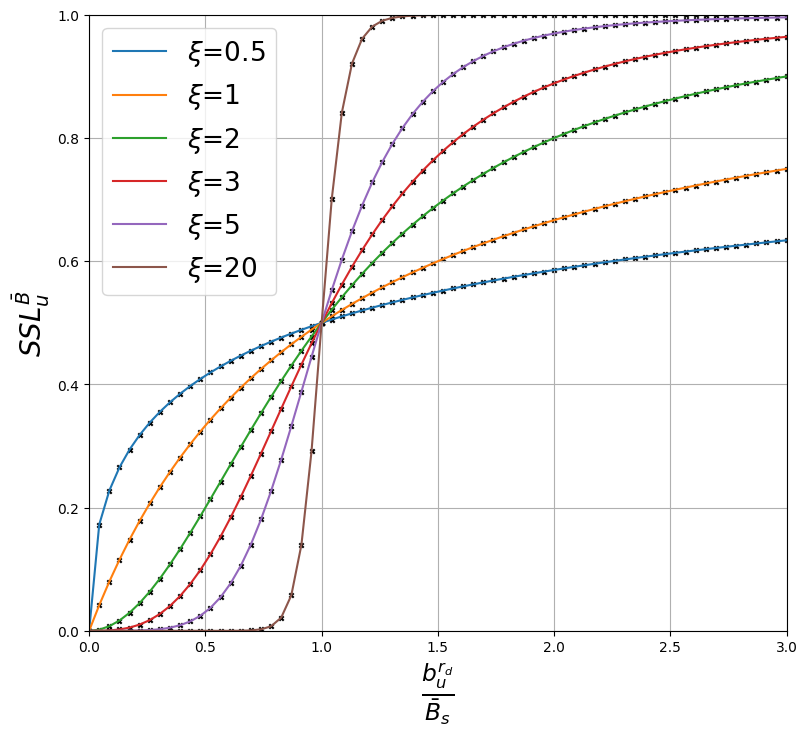

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function
def sigmoid_like(r, R, Y):
    return (r / R) ** Y / (1 + (r / R) ** Y)

# Define the range for r/R
r_R = np.linspace(0, 3, 70)

# Define the values for Y
Y_values = [0.5,1,2,3,5,20]

# Plotting
plt.figure(figsize=(9, 8))

for Y in Y_values:
    F = sigmoid_like(r_R, 1, Y)  # R=1 for simplicity
    plt.plot(r_R, F, label=r'$\xi$='+str(Y))https://www.linkedin.com/in/ashkanroshanayi/

    # Plot points with circle markers
    for i in range(len(r_R)):
        if i % 1 == 0:  # Plot points for every 0.01 of r/R
            plt.scatter(r_R[i], F[i], color='black', s=10, marker='x')

#plt.title(r'${SSL}^{\bar{B}}_u$')
plt.xlabel(r'$\frac{b_u^{r_d}}{\bar{B}_s}$', fontsize=24)
plt.ylabel(r'${SSL}^{\bar{B}}_u$', fontsize=20)
plt.legend(fontsize=19)  # Adjust fontsize
plt.grid(True)
plt.xlim(0, 3)
plt.ylim(0, 1)
plt.show()

In [1]:
import numpy as np

USER_NO = 10
X_LIM = 100  # Example value for X_LIM, you can set this to any desired value

# Initialize loc_user array with zeros
loc_user = np.zeros((1, USER_NO, 2))  # Assuming t = 1 for initialization

# Calculate the number of users per edge
users_per_edge = USER_NO // 4
extra_users = USER_NO % 4

# Function to distribute users along an edge
def distribute_users(start, end, num_users):
    return [start + (end - start) * i / (num_users + 1) for i in range(1, num_users + 1)]

# Distribute users along the edges
user_index = 0

# Bottom edge (x varies from 0 to X_LIM, y = 0)
for x in distribute_users(0, X_LIM, users_per_edge + (1 if extra_users > 0 else 0)):
    loc_user[0, user_index, 0] = x
    loc_user[0, user_index, 1] = 0
    user_index += 1
    extra_users -= 1

# Right edge (x = X_LIM, y varies from 0 to X_LIM)
for y in distribute_users(0, X_LIM, users_per_edge + (1 if extra_users > 0 else 0)):
    loc_user[0, user_index, 0] = X_LIM
    loc_user[0, user_index, 1] = y
    user_index += 1
    extra_users -= 1

# Top edge (x varies from X_LIM to 0, y = X_LIM)
for x in distribute_users(X_LIM, 0, users_per_edge + (1 if extra_users > 0 else 0)):
    loc_user[0, user_index, 0] = x
    loc_user[0, user_index, 1] = X_LIM
    user_index += 1
    extra_users -= 1

# Left edge (x = 0, y varies from X_LIM to 0)
for y in distribute_users(X_LIM, 0, users_per_edge + (1 if extra_users > 0 else 0)):
    loc_user[0, user_index, 0] = 0
    loc_user[0, user_index, 1] = y
    user_index += 1
    extra_users -= 1

# Display the initialized locations
print("Initial user locations:")
print(loc_user)


Initial user locations:
[[[ 25.           0.        ]
  [ 50.           0.        ]
  [ 75.           0.        ]
  [100.          33.33333333]
  [100.          66.66666667]
  [ 66.66666667 100.        ]
  [ 33.33333333 100.        ]
  [  0.          66.66666667]
  [  0.          33.33333333]
  [  0.           0.        ]]]


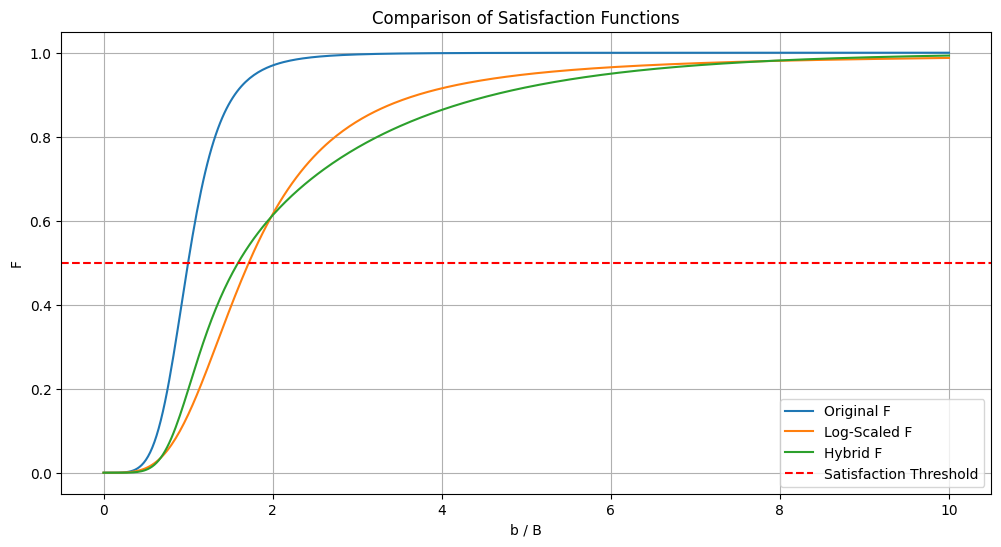

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def original_F(b, B, gamma):
    ratio = b / B
    return (ratio ** gamma) / (1 + ratio ** gamma)

def capped_F(b, B, gamma):
    ratio = b / B
    return min(1, (ratio ** gamma) / (1 + ratio ** gamma))

def log_scaled_F(b, B, gamma):
    ratio = np.log(1 + b / B)
    return (ratio ** gamma) / (1 + ratio ** gamma)

def hybrid_F(b, B, gamma, beta):
    ratio = b / B
    base = (ratio ** gamma) / (1 + ratio ** gamma)
    penalty = 1 - np.exp(-beta * ratio)
    return base * penalty

b_B_ratios = np.linspace(0, 10, 400)
gamma = 5
beta = 0.5
B = 1  # Normalize B to 1 for simplicity

plt.figure(figsize=(12, 6))
plt.plot(b_B_ratios, original_F(b_B_ratios, B, gamma), label='Original F')
#plt.plot(b_B_ratios, capped_F(b_B_ratios, B, gamma), label='Capped F')
plt.plot(b_B_ratios, log_scaled_F(b_B_ratios, B, gamma), label='Log-Scaled F')
plt.plot(b_B_ratios, hybrid_F(b_B_ratios, B, gamma, beta), label='Hybrid F')
plt.axhline(y=0.5, color='r', linestyle='--', label='Satisfaction Threshold')
plt.xlabel('b / B')
plt.ylabel('F')
plt.legend()
plt.title('Comparison of Satisfaction Functions')
plt.grid(True)
plt.show()